In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Project 1: Ringing Effect

read the image first

Shape: (800, 800)
Data type: float64
MAX value: 255.0
MIN value: 0.0


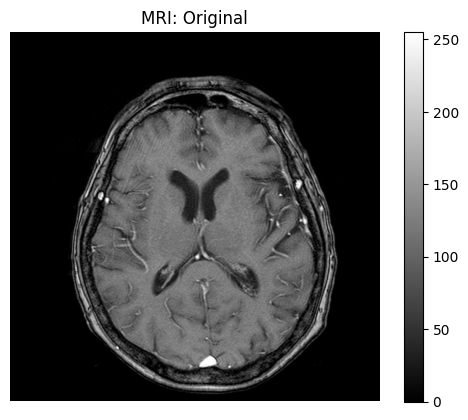

In [2]:
# open the iamge lab3.npy
img = np.load('./input/lab3.npy')

# show the infromation of the image
print("Shape:", img.shape)
print("Data type:", img.dtype)
print("MAX value:", img.max())
print("MIN value:", img.min())

# show the image
plt.imshow(img, cmap='gray')
plt.colorbar()
plt.title("MRI: Original")
plt.axis('off')
plt.show()

### Lowpass Filter: Ideal Low-pass

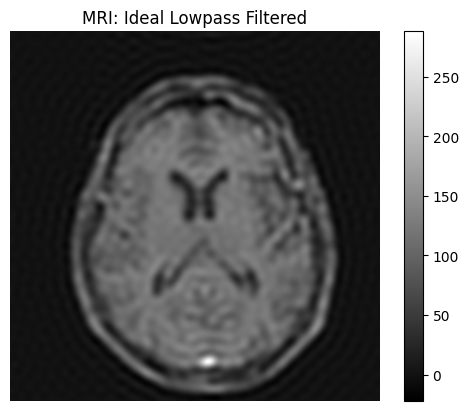

In [3]:
""" Get H: H = 1, when r <= D_0 """
# get the shape of the image
rows, cols = img.shape
# get the axises of the image
u = np.arange(rows) - rows // 2
v = np.arange(cols) - cols // 2
# get the meshgrid of the axises
U, V = np.meshgrid(u, v)
D = np.sqrt(U**2 + V**2)

# set D_0
D_0 = 30

# get Ideal Lowpass Filter: H
H_ideal = (D <= D_0).astype(float)

""" Apply the filter: G = H * F """
# transform the iamge to frequency domain
F = np.fft.fftshift(np.fft.fft2(img))
# apply the filter: multiply pixel by pixel
G_ideal = H_ideal * F
g_ideal = np.fft.ifft2(np.fft.ifftshift(G_ideal)).real

# show the image
plt.imshow(g_ideal, cmap='gray')
plt.colorbar()
plt.title("MRI: Ideal Lowpass Filtered")
plt.axis('off')
plt.show()


实现滤波部分操作比较统一，只需要修改应用的滤波器即可，因此考虑将滤波操作封装成函数。

In [4]:
# function: apply the filter
def applyFrequencyFilter(img, H):
    F = np.fft.fftshift(np.fft.fft2(img))
    G = H * F
    g = np.fft.ifft2(np.fft.ifftshift(G)).real
    return g

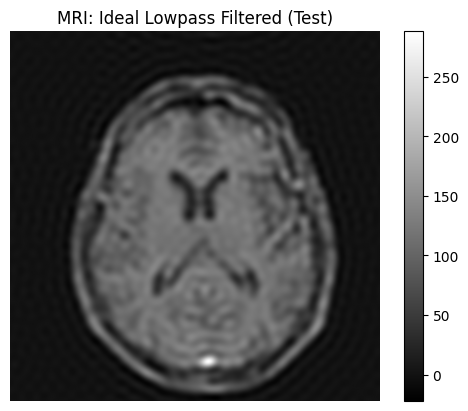

In [5]:
# test: ideal lowpass filter
g_ideal_test = applyFrequencyFilter(img, H_ideal)
# show the image
plt.imshow(g_ideal_test, cmap='gray')
plt.colorbar()
plt.title("MRI: Ideal Lowpass Filtered (Test)")
plt.axis('off')
plt.show()

测试通过，接下来只需要写不同的滤波器即可。

### Lowpass Filter: Ideal Low-pass, Butterworth(n = 6), Gaussian

AttributeError: 'Axes' object has no attribute 'colorbar'

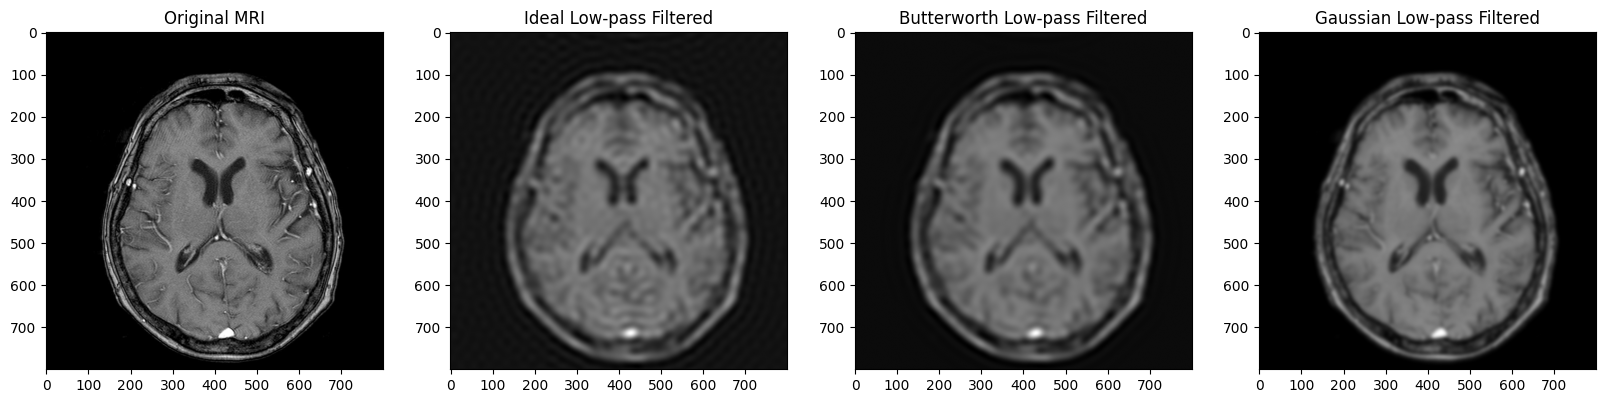

In [6]:
""" Low-pass Filters """
# 1. Ideal Low-pass Filter: H_ideal
H_ideal = (D <= D_0).astype(float)
# 2. Butterworth Low-pass Filter: H_butterworth
n = 6
H_butterworth = 1 / (1 + (D / D_0)**(2 * n))
# 3. Gaussian Low-pass Filter: H_gaussian
H_gaussian = np.exp(-(D**2) / (2 * (D_0**2)))


""" Apply the Filters """
# 1. Ideal Low-pass Filter
g_ideal = applyFrequencyFilter(img, H_ideal)
# 2. Butterworth Low-pass Filter
g_butterworth = applyFrequencyFilter(img, H_butterworth)
# 3. Gaussian Low-pass Filter
g_gaussian = applyFrequencyFilter(img, H_gaussian)


""" Show the Images """
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original MRI')
ax[1].imshow(g_ideal, cmap='gray')
ax[1].set_title('Ideal Low-pass Filtered')
ax[2].imshow(g_butterworth, cmap='gray')
ax[2].set_title('Butterworth Low-pass Filtered')
ax[3].imshow(g_gaussian, cmap='gray')
ax[3].set_title('Gaussian Low-pass Filtered')
for a in ax:
    a.colorbar()
    a.axis('off')
plt.show()

报错原因：a 是一个 Axes 类型变量，不能实现添加 colorbar 的操作。去掉即可。

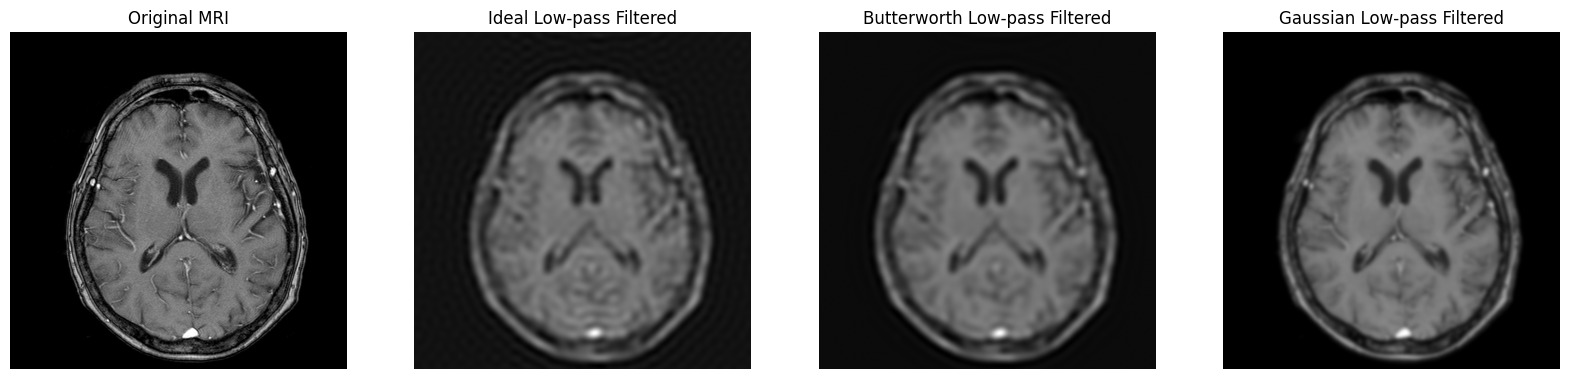

In [7]:
""" Low-pass Filters """
# 1. Ideal Low-pass Filter: H_ideal
H_ideal = (D <= D_0).astype(float)
# 2. Butterworth Low-pass Filter: H_butterworth
n = 6
H_butterworth = 1 / (1 + (D / D_0)**(2 * n))
# 3. Gaussian Low-pass Filter: H_gaussian
H_gaussian = np.exp(-(D**2) / (2 * (D_0**2)))


""" Apply the Filters """
# 1. Ideal Low-pass Filter
g_ideal = applyFrequencyFilter(img, H_ideal)
# 2. Butterworth Low-pass Filter
g_butterworth = applyFrequencyFilter(img, H_butterworth)
# 3. Gaussian Low-pass Filter
g_gaussian = applyFrequencyFilter(img, H_gaussian)


""" Show the Images """
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original MRI')
ax[1].imshow(g_ideal, cmap='gray')
ax[1].set_title('Ideal Low-pass Filtered')
ax[2].imshow(g_butterworth, cmap='gray')
ax[2].set_title('Butterworth Low-pass Filtered')
ax[3].imshow(g_gaussian, cmap='gray')
ax[3].set_title('Gaussian Low-pass Filtered')
for a in ax:
    a.axis('off')
plt.show()

### Point out the ringing effect and explain the cause

理想低通滤波器在图像边缘会产生水波纹状的“振铃效应”，也就是 Ringing Effect。

这是因为：频率域中的非常突兀的阶跃截断在空间域对应的脉冲响应是 Sinc 函数，Sinc 函数具有无限延伸的旁瓣。除了高斯滤波器外，其他滤波器不可避免在空间上存在部分旁瓣能量，因此都有 Ringing Effect。高斯滤波器的傅里叶变换结果还是高斯函数，因此没有旁瓣，在图像上就是变模糊了，但是没有所谓的 Ringing Effect。

可以对一个白点进行滤波，可以清晰观察以上现象。

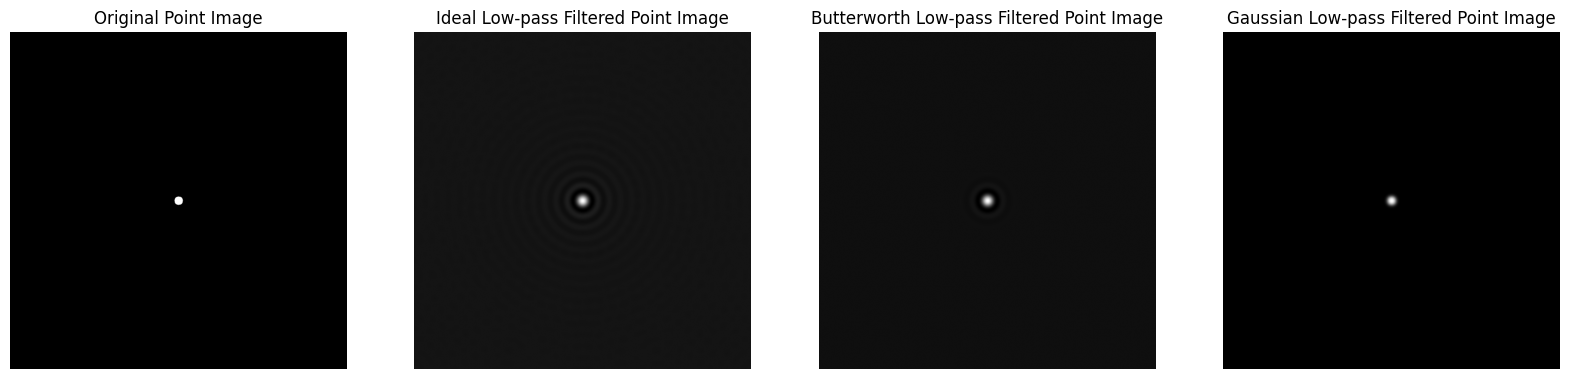

In [8]:
# white point image
point_img = (D <= 10).astype(float)


# Apply the Filters
# 1. Ideal Low-pass Filter
point_g_ideal = applyFrequencyFilter(point_img, H_ideal)
# 2. Butterworth Low-pass Filter
point_g_butterworth = applyFrequencyFilter(point_img, H_butterworth)
# 3. Gaussian Low-pass Filter
point_g_gaussian = applyFrequencyFilter(point_img, H_gaussian)

# Show the Images
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(point_img, cmap='gray')
ax[0].set_title('Original Point Image')
ax[1].imshow(point_g_ideal, cmap='gray')
ax[1].set_title('Ideal Low-pass Filtered Point Image')
ax[2].imshow(point_g_butterworth, cmap='gray')
ax[2].set_title('Butterworth Low-pass Filtered Point Image')
ax[3].imshow(point_g_gaussian, cmap='gray')
ax[3].set_title('Gaussian Low-pass Filtered Point Image')
for a in ax:
    a.axis('off')
plt.show()

## Project 2: Identical Filter

### Implement a spatial filter

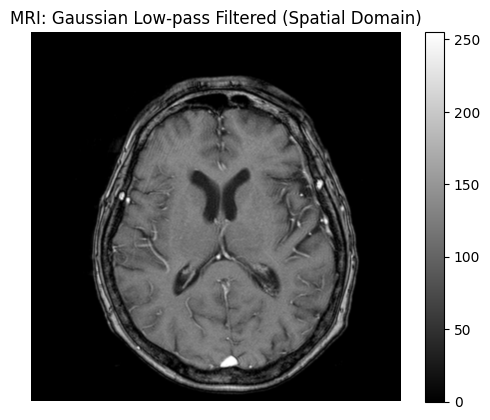

In [9]:
"""  Low pass Gaussian Filter: sigma = 1 """
# set sigma
sigma = 1
# caculate the kernel size: 3 sigma rule
k_size = 6 * sigma + 1

# create the Gaussian kernel
kernel_axises = np.arange(-k_size // 2 + 1, k_size // 2 + 1)
X, Y = np.meshgrid(kernel_axises, kernel_axises)
kernel_gaussian = np.exp(-(X**2 + Y**2) / (2 * (sigma**2)))

# normalize the kernel
kernel_gaussian /= kernel_gaussian.sum()

""" Apply the Gaussian Filter in spatial domain """
# padding the image
kernel_padding = k_size // 2
padded_img = np.pad(img, kernel_padding, mode='edge')
result_gaussian_spatial = np.zeros_like(img, dtype=float)

# convolution
for i in range(k_size):
    for j in range(k_size):
        result_gaussian_spatial += kernel_gaussian[i, j] * padded_img[i:i + img.shape[0], j:j + img.shape[1]]

# show the iamge
plt.imshow(result_gaussian_spatial, cmap='gray')
plt.colorbar()
plt.title("MRI: Gaussian Low-pass Filtered (Spatial Domain)")
plt.axis('off')
plt.show()


看不出啥效果，但是因为 sigma = 1，本来应该也没有很大的模糊。

生成高斯卷积核和卷积部分先封装一下。

In [10]:
# generate Gaussian Kernal
def generateGaussianKernal(sigma):
    # calculate kernel size
    kernel_size = 6 * sigma + 1
    # create the Gaussian kernel
    kernel_axises = np.arange(-kernel_size // 2 + 1, kernel_size // 2 + 1)
    X, Y = np.meshgrid(kernel_axises, kernel_axises)
    kernel_gaussian = np.exp(-(X**2 + Y**2) / (2 * (sigma**2)))
    # normalize the kernel
    return kernel_gaussian / kernel_gaussian.sum()

# calculate 2d convolution
def numpy_conv2d(image, kernel):
    # padding the image
    kernel_height, kernel_width = kernel.shape
    padding_height, padding_width = kernel_height // 2, kernel_width // 2
    padded_img = np.pad(image, ((padding_height, padding_height), (padding_width, padding_width)), mode='edge')

    # calculate the result
    result = np.zeros_like(image, dtype=float)
    for i in range(kernel_height):
        for j in range(kernel_width):
            result += kernel[i, j] * padded_img[i:i+image.shape[0], j:j+image.shape[1]]

    return result


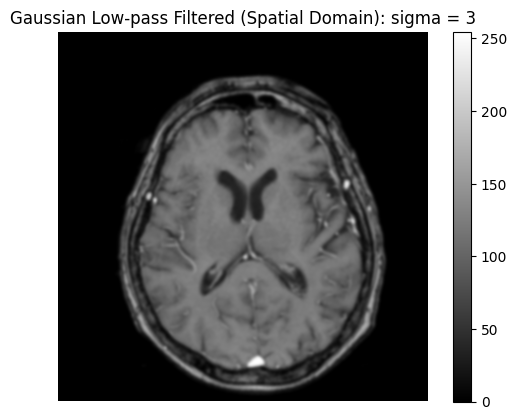

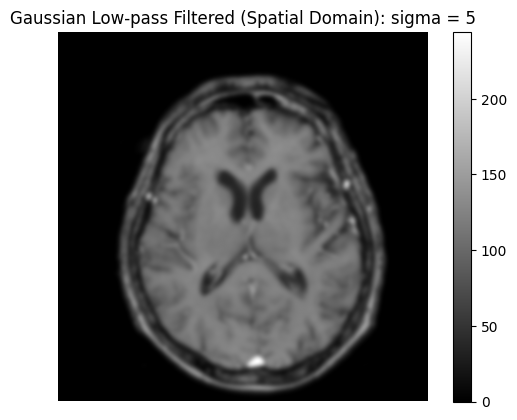

In [12]:
# test 
kernel_gaussian_3 = generateGaussianKernal(3)
img_spatial_lp_3 = numpy_conv2d(img, kernel_gaussian_3)
kernel_gaussian_5 = generateGaussianKernal(5)
img_spatial_lp_5 = numpy_conv2d(img, kernel_gaussian_5)

# show the image
plt.imshow(img_spatial_lp_3, cmap='gray')
plt.colorbar()
plt.title("Gaussian Low-pass Filtered (Spatial Domain): sigma = 3")
plt.axis('off')
plt.show()

plt.imshow(img_spatial_lp_5, cmap='gray')
plt.colorbar()
plt.title("Gaussian Low-pass Filtered (Spatial Domain): sigma = 5")
plt.axis('off')
plt.show()

从 sigma = 1 到 sigma = 5 的变化中，图像的模糊还是挺明显的。低通效果不错。高通就是原图减去低通。

In [ ]:
# lowpass filter
kernel_gaussian_1 = generateGaussianKernal(1)
img_spatial_lp_1 = numpy_conv2d(img, kernel_gaussian_1)
img_spatial_hp_1 = img - img_spatial_lp_1
kernel_gaussian_3 = generateGaussianKernal(3)
img_spatial_lp_3 = numpy_conv2d(img, kernel_gaussian_3)
img_spatial_hp_3 = img - img_spatial_lp_3
kernel_gaussian_5 = generateGaussianKernal(5)
img_spatial_lp_5 = numpy_conv2d(img, kernel_gaussian_5)
img_spatial_hp_5 = img - img_spatial_lp_5

# show the images
fig, ax = plt.subplots(2, 3, figsize=(20, 5))
ax[0, 0].imshow(img_spatial_lp_1, cmap='gray')
ax[0, 0].set_title('Lowpass: sigma = 1')
ax[0, 1].imshow(img_spatial_lp_3, cmap='gray')
ax[0, 1].set_title('Lowpass: sigma = 3')
ax[0, 2].imshow(img_spatial_lp_5, cmap='gray')
ax[0, 2].set_title('Highpass: sigma = 5')
ax[1, 0].imshow(img_spatial_hp_1, cmap='gray')
ax[1, 0].set_title('Highpass: sigma = 1')
ax[1, 1].imshow(img_spatial_hp_3, cmap='gray')
ax[1, 1].set_title('Highpass: sigma = 3')
ax[1, 2].imshow(img_spatial_hp_5, cmap='gray')
ax[1, 2].set_title('Highpass: sigma = 5')